In [3]:
# Import necessary packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from numpy.polynomial import Polynomial

from polar_express import optimal_composition

In [4]:
ell = 0.03 # Lower bound on singular values
n_steps = 3 # Number of steps in PolarExpress

# Compute coefficients
coefficients = optimal_composition(
    l=ell,
    num_iters=n_steps,
    safety_factor_eps=0.0,
    cushion=0.0,
)

# Compute polynomials
polynomials = [
    Polynomial([0, a, 0, b, 0, c])
    for a, b, c in coefficients
]

# Print the polynomials
for i, poly in enumerate(polynomials, start=1):
    print(f"p_{i}(x) = {poly}")

p_1(x) = 0.0 + 7.36252776·x + 0.0·x² - 20.74339565·x³ + 0.0·x⁴ + 15.16055176·x⁵
p_2(x) = 0.0 + 2.91753804·x + 0.0·x² - 2.18240538·x³ + 0.0·x⁴ + 0.47552922·x⁵
p_3(x) = 0.0 + 2.04631011·x + 0.0·x² - 1.429475·x³ + 0.0·x⁴ + 0.39335241·x⁵


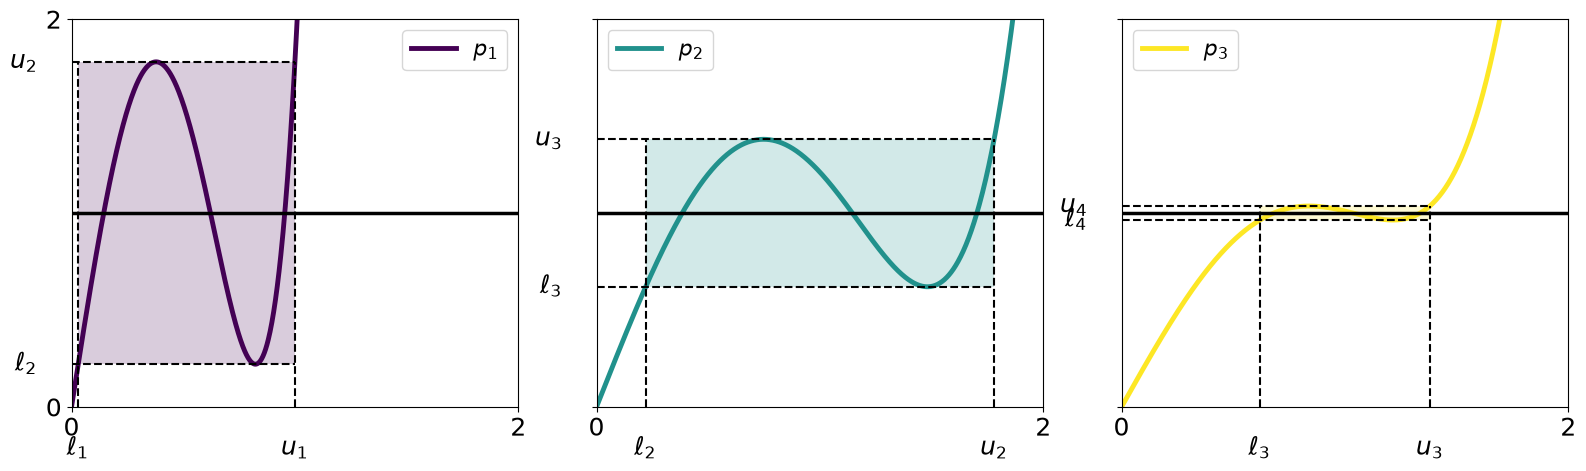

In [5]:
# Plot the polynomials

x_grid = np.linspace(0, 2, 1000)

fig, axes = plt.subplots(
    1,
    n_steps,
    figsize=(5.3 * n_steps, 4.8),
    sharey=True,
)

# Handle the n_steps = 1 case
if n_steps == 1:
    axes = [axes]

lower_bound = ell
upper_bound = 1.0

cmap = plt.get_cmap("viridis")

for i, (ax, poly) in enumerate(zip(axes, polynomials)):
    color = cmap(i / max(n_steps - 1, 1))

    # Plot p_i
    ax.plot(
        x_grid,
        poly(x_grid),
        color=color,
        linewidth=3.5,
        label=rf"$p_{i+1}$",
    )

    # Input interval
    old_lower = lower_bound
    old_upper = upper_bound

    # Output interval
    lower_bound = poly(old_lower)
    upper_bound = 2 - lower_bound

    # Labels for input interval
    ax.text(
        old_lower,
        -0.15,
        rf"$\ell_{i+1}$",
        fontsize=18,
        ha="center",
        va="top",
    )

    ax.text(
        old_upper,
        -0.15,
        rf"$u_{i+1}$",
        fontsize=18,
        ha="center",
        va="top",
    )

    # Labels for output interval
    ax.text(
        -0.15,
        lower_bound,
        rf"$\ell_{i+2}$",
        fontsize=18,
        ha="right",
        va="center",
    )

    ax.text(
        -0.15,
        upper_bound,
        rf"$u_{i+2}$",
        fontsize=18,
        ha="right",
        va="center",
    )

    # Dashed interval guides
    ax.plot(
        [old_lower, old_lower],
        [0, upper_bound],
        color="black",
        linestyle="--",
    )

    ax.plot(
        [old_upper, old_upper],
        [0, upper_bound],
        color="black",
        linestyle="--",
    )

    ax.plot(
        [0, old_upper],
        [lower_bound, lower_bound],
        color="black",
        linestyle="--",
    )

    ax.plot(
        [0, old_upper],
        [upper_bound, upper_bound],
        color="black",
        linestyle="--",
    )

    # Shade the mapping of the interval
    rect = patches.Rectangle(
        (old_lower, lower_bound),
        old_upper - old_lower,
        upper_bound - lower_bound,
        linewidth=1,
        edgecolor="none",
        facecolor=color,
        alpha=0.2,
    )
    ax.add_patch(rect)

    # Target sign function on the positive half-axis
    ax.plot(x_grid, np.ones_like(x_grid), color="black", linewidth=2.5)

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xticks([0, 2])
    ax.legend(fontsize=16)
    ax.tick_params(axis="both", labelsize=18)

axes[0].set_yticks([0, 2])

plt.tight_layout()
plt.show()